In [29]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
from scipy.stats import pearsonr
from power_law_fit import read_edgelist_from_csv,plot_degree_distribution,fit_powerlaw
from collections import Counter
import Graph_Sampling
import pandas as pd

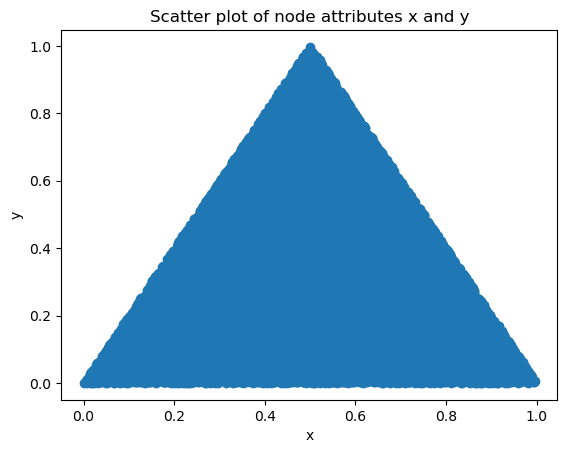

In [2]:
# Sample graph (replace with your graph)
# Read the graph from a GraphML file
G = nx.read_graphml("data/homophilic_model_linear.graphml")
mapping = {node: int(node) for node in G.nodes()}
G = nx.relabel_nodes(G, mapping) # turn the node label into intergers, as the configuration model has
# Print some information about the graph


# Extract x and y attributes
x_values = nx.get_node_attributes(G, 'x')
y_values = nx.get_node_attributes(G, 'y')

# Plotting scatter plot
plt.scatter(list(x_values.values()), list(y_values.values()))
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of node attributes x and y')
plt.show()

(array([668., 602., 579., 566., 593., 590., 593., 577., 560., 547., 503.,
        504., 505., 529., 539., 469., 531., 516., 486., 485., 477., 451.,
        475., 484., 424., 457., 447., 432., 374., 420., 418., 430., 401.,
        366., 419., 381., 383., 381., 382., 333., 334., 352., 345., 366.,
        377., 292., 319., 313., 342., 292., 310., 267., 282., 277., 303.,
        244., 264., 230., 248., 226., 229., 211., 240., 226., 209., 214.,
        211., 186., 207., 206., 178., 160., 161., 157., 152., 140., 121.,
        127., 138., 117., 104., 112.,  94., 113.,  85.,  88.,  75.,  67.,
         63.,  52.,  61.,  42.,  47.,  33.,  46.,  21.,  25.,  11.,   8.,
          3.]),
 array([4.89287205e-06, 9.97831287e-03, 1.99517329e-02, 2.99251529e-02,
        3.98985728e-02, 4.98719928e-02, 5.98454128e-02, 6.98188328e-02,
        7.97922528e-02, 8.97656728e-02, 9.97390928e-02, 1.09712513e-01,
        1.19685933e-01, 1.29659353e-01, 1.39632773e-01, 1.49606193e-01,
        1.59579613e-01, 1.6955

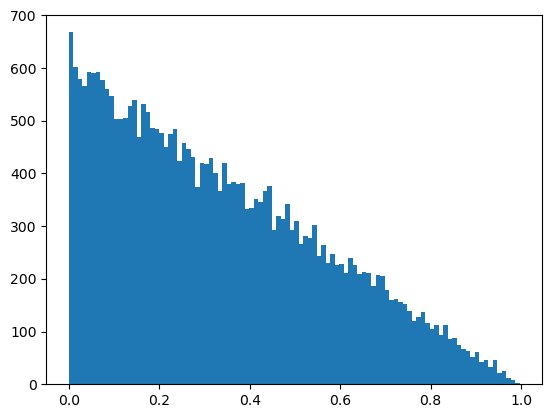

In [5]:
plt.hist(list(y_values.values()),bins=100)

In [8]:
file_path = 'data/Libra.csv'
G = read_edgelist_from_csv(file_path,create_using='directed')

In [3]:

total_nodes = G.number_of_nodes()
total_degrees = [G.in_degree(n) + G.out_degree(n) for n in G.nodes()]
degree_count = Counter(total_degrees)
degree_proportions = {degree: count / total_nodes for degree, count in degree_count.items()}

# Print the proportions for each total degree
print(f"Total Degree 1: {degree_proportions[1]}")



AttributeError: 'Graph' object has no attribute 'in_degree'

In [20]:
# 1. Convert to a directed graph by randomly assigning directions to undirected edges
G_directed = nx.DiGraph()
for u, v in G.edges():
    if random.random() < 0.5:
        G_directed.add_edge(u, v)
    else:
        G_directed.add_edge(v, u)

# Calculate the total degree for each node
total_nodes = G_directed.number_of_nodes()
total_degrees = [G_directed.in_degree(n) + G_directed.out_degree(n) for n in G_directed.nodes()]
degree_count = Counter(total_degrees)
degree_proportions = {degree: count / total_nodes for degree, count in degree_count.items()}

# Print the proportions for each total degree
print(f"Total Degree 1: {degree_proportions[1]}")

Total Degree 1: 0.33013333333333333


In [21]:
print(f"Total Degree 2: {degree_proportions[2]}") 

Total Degree 2: 0.33666666666666667


In [22]:
print(f"Total Degree 2: {degree_proportions[3]}")

Total Degree 2: 0.13483333333333333


In [23]:
G_modified = G_directed.copy()
# Function to randomly remove an edge from a node with total degree > 1
def remove_random_edge(graph):
    # Get all nodes with total degree greater than 1
    eligible_nodes = [node for node in graph.nodes() if graph.degree(node) > 1]
    
    if not eligible_nodes:
        return  # Stop if no eligible nodes are found
    node = random.choice(eligible_nodes)
    
    # Get all edges of this node (both in and out)
    edges = list(graph.edges(node)) + list(graph.in_edges(node))
    
    if edges:
        # Randomly select an edge to remove
        edge_to_remove = random.choice(edges)
        graph.remove_edge(*edge_to_remove)

# Repeat the process 1000 times
for _ in range(20000):
    remove_random_edge(G_modified)


In [24]:
total_nodes = G_modified.number_of_nodes()
total_degrees = [G_modified.in_degree(n) + G_modified.out_degree(n) for n in G.nodes()]
degree_count = Counter(total_degrees)
degree_proportions = {degree: count / total_nodes for degree, count in degree_count.items()}

# Print the proportions for each total degree
print(f"Total Degree 1: {degree_proportions[1]}")

Total Degree 1: 0.6188333333333333


In [25]:
print(f"Total Degree 2: {degree_proportions[2]}") 

Total Degree 2: 0.10586666666666666


In [26]:
print(f"Total Degree 3: {degree_proportions[3]}") 

Total Degree 3: 0.0471


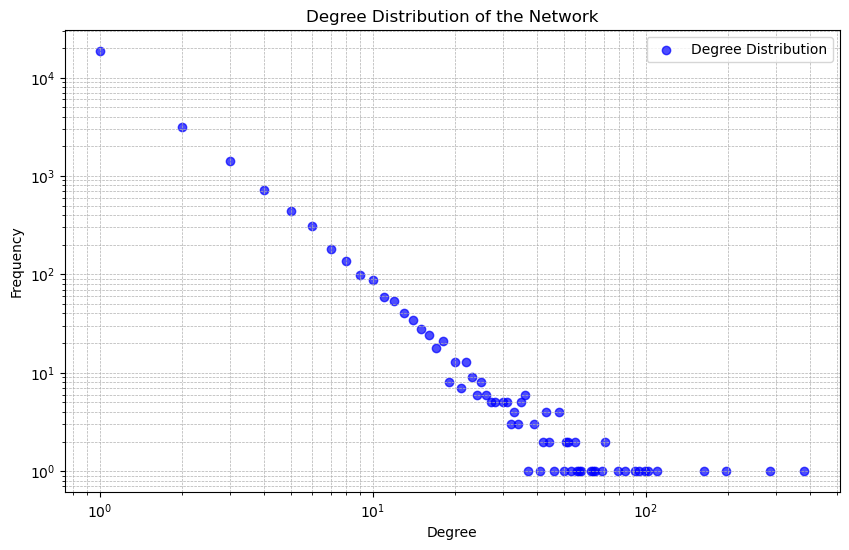

In [27]:
degree = plot_degree_distribution(G_modified,directed=True)